# Study Hours Project

## Project Description
This project analyzes my study habits using manually collected daily data.  
The dataset includes:

- **Date**
- **Hours studied**
- **Class**

I am interested in this data because I want to better understand my study habits, measure my productivity, and see how my study hours change across different subjects.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load the Dataset
The data was collected manually and stored in a CSV file.

In [2]:
df = pd.read_csv("Data_Project.csv")
df.head()

,Date,Hours,Class
0,2026-02-09,1.0,PHIL-201
1,2026-02-09,3.0,COMM-432
2,2026-02-09,2.0,CPSC-222
3,2026-02-09,4.0,ECON-451
4,2026-02-09,4.0,ECON-489


## 2. Data Validation
Because the dataset was entered manually, it is already mostly clean.  
However, I still checked the structure, column types, and missing values to confirm that the dataset is ready for analysis.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4136 entries, 0 to 4135
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    426 non-null    object 
 1   Hours   426 non-null    float64
 2   Class   426 non-null    object 
dtypes: float64(1), object(2)
memory usage: 97.1+ KB


In [4]:
df.isnull().sum()

Date     3710
Hours    3710
Class    3710
dtype: int64

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Hours'] = pd.to_numeric(df['Hours'])

In [6]:
df.head()

,Date,Hours,Class
0,2026-02-09,1.0,PHIL-201
1,2026-02-09,3.0,COMM-432
2,2026-02-09,2.0,CPSC-222
3,2026-02-09,4.0,ECON-451
4,2026-02-09,4.0,ECON-489


## 3. Descriptive Statistics
This section summarizes the dataset.

In [7]:
df.describe()

,Date,Hours
count,426,426.000000
mean,2026-03-16 00:00:00,0.753521
min,2026-02-09 00:00:00,0.000000
25%,2026-02-26 00:00:00,0.000000
50%,2026-03-16 00:00:00,0.000000
75%,2026-04-03 00:00:00,1.000000
max,2026-04-20 00:00:00,4.000000
std,NaN,0.931943


In [8]:
print("Number of rows:", len(df))
print("Unique classes:", df['Class'].unique())

Number of rows: 4136
Unique classes: ['PHIL-201' 'COMM-432' 'CPSC-222' 'ECON-451' 'ECON-489' 'MATH-454' nan]


## 4. Visualizations

### Visualization 1: Total Study Hours Per Day

This visualization shows how my study time changes over time and helps identify patterns in daily productivity.

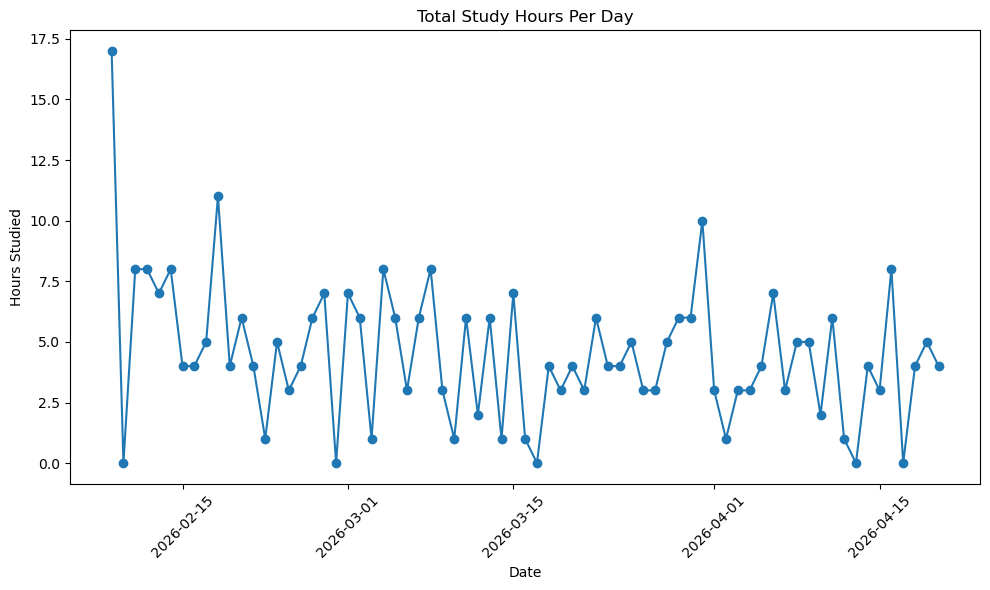

In [9]:
daily_hours = df.groupby('Date')['Hours'].sum()

plt.figure(figsize=(10,6))
plt.plot(daily_hours.index, daily_hours.values, marker='o')
plt.title('Total Study Hours Per Day')
plt.xlabel('Date')
plt.ylabel('Hours Studied')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualization 2: Total Study Hours by Class

This visualization compares the total amount of time spent on each subject.

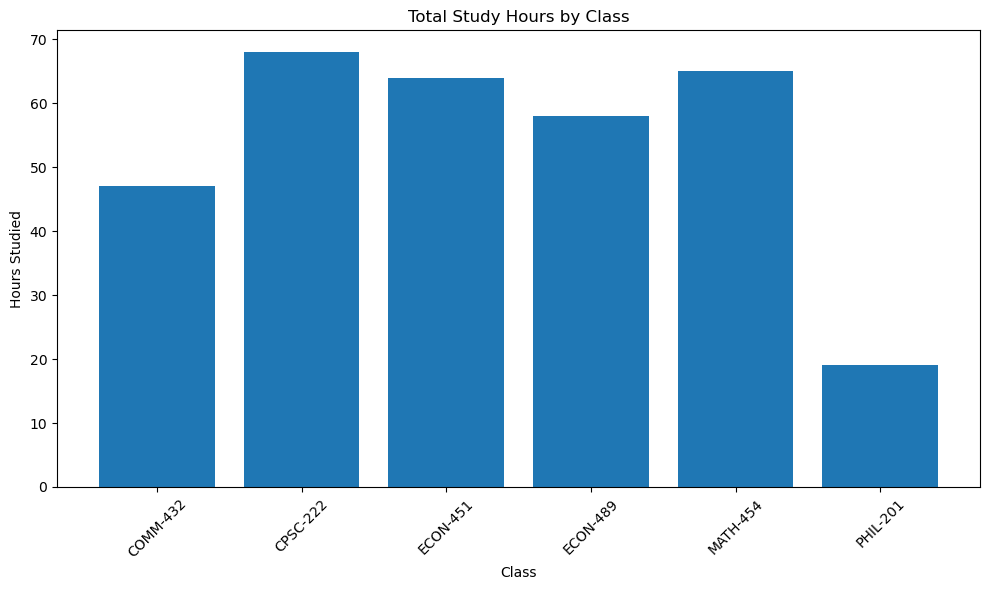

In [10]:
subject_hours = df.groupby('Class')['Hours'].sum()

plt.figure(figsize=(10,6))
plt.bar(subject_hours.index, subject_hours.values)
plt.title('Total Study Hours by Class')
plt.xlabel('Class')
plt.ylabel('Hours Studied')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Hypothesis Testing

I want to test whether my average daily study time is greater than 2 hours.

### Hypotheses:
- Null hypothesis (H0): Average daily study time = 2 hours
- Alternative hypothesis (H1): Average daily study time > 2 hours

In [11]:
daily_hours = df.groupby('Date')['Hours'].sum()

In [12]:
t_stat, p_value_two_tailed = stats.ttest_1samp(daily_hours, 2)

In [13]:
# Convert to one-tailed p-value
if t_stat > 0:
    p_value = p_value_two_tailed / 2
else:
    p_value = 1 - (p_value_two_tailed / 2)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 7.3189801709510895
P-value: 1.6313048317636047e-10


## 6. Hypothesis Test Result

If the p-value is less than 0.05, we reject the null hypothesis.
Otherwise, we fail to reject the null hypothesis.

In [14]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is evidence that my average daily study time is greater than 2 hours.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that my average daily study time is greater than 2 hours.")

Reject the null hypothesis.
There is evidence that my average daily study time is greater than 2 hours.


## 7. Conclusion

This project analyzed my study habits using manually collected data.

### Key points:
- I tracked study hours by date and subject.
- Visualizations showed how my study time changes over time and across subjects.
- A hypothesis test was used to evaluate whether I study more than 2 hours per day.

Overall, this analysis helps me better understand my productivity and how I allocate time between different classes.